<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/K_means_clustering_ELbow_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Healthcare_Patient_Segmentation_Realistic.csv to Healthcare_Patient_Segmentation_Realistic.csv


In [2]:
import pandas as pd

df = pd.read_csv(
    "Healthcare_Patient_Segmentation_Realistic.csv"
)

df.head()

,Patient_ID,Age,Gender,BMI,Monthly_Visits,Annual_Medical_Expenses,Chronic_Conditions,Medication_Count,Hospitalizations_Last_Year,Health_Risk_Score,Insurance_Coverage
0,PAT00001,24,Female,25.6,2,26575,0,0,0,11,237337
1,PAT00002,28,Male,24.9,2,6685,0,1,0,28,294027
2,PAT00003,23,Female,19.5,0,22568,1,1,0,26,358795
3,PAT00004,34,Male,22.9,1,23431,1,2,0,19,481490
4,PAT00005,29,Male,25.9,0,16394,0,2,0,11,356840


In [3]:
df.shape

(10000, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  10000 non-null  object 
 1   Age                         10000 non-null  int64  
 2   Gender                      10000 non-null  object 
 3   BMI                         10000 non-null  float64
 4   Monthly_Visits              10000 non-null  int64  
 5   Annual_Medical_Expenses     10000 non-null  int64  
 6   Chronic_Conditions          10000 non-null  int64  
 7   Medication_Count            10000 non-null  int64  
 8   Hospitalizations_Last_Year  10000 non-null  int64  
 9   Health_Risk_Score           10000 non-null  int64  
 10  Insurance_Coverage          10000 non-null  int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 859.5+ KB


In [5]:
X = df[
    [
        "Age",
        "BMI",
        "Monthly_Visits",
        "Annual_Medical_Expenses",
        "Chronic_Conditions",
        "Medication_Count",
        "Hospitalizations_Last_Year",
        "Health_Risk_Score"
    ]
]

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

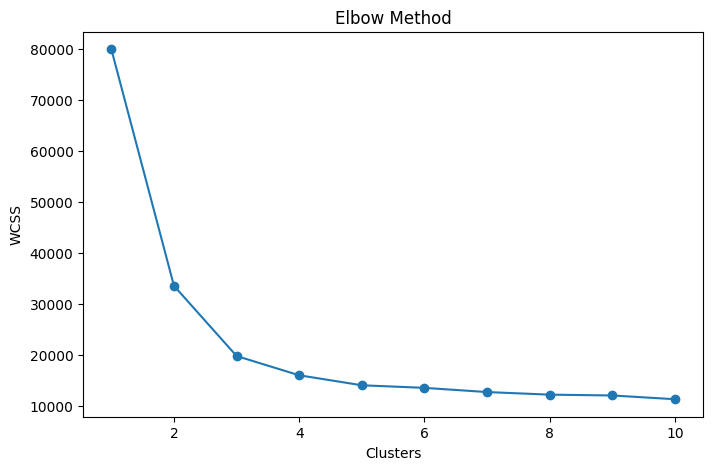

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [9]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        "Clusters:",
        k,
        "Score:",
        round(score,3)
    )

Clusters: 2 Score: 0.501
Clusters: 3 Score: 0.512
Clusters: 4 Score: 0.4
Clusters: 5 Score: 0.337
Clusters: 6 Score: 0.287
Clusters: 7 Score: 0.269
Clusters: 8 Score: 0.268
Clusters: 9 Score: 0.255
Clusters: 10 Score: 0.239


In [14]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

In [15]:
df["Cluster"].value_counts()

,count
Cluster,
4,2525
0,2481
2,2372
3,1628
1,994


In [16]:
cluster_profile = df.groupby(
    "Cluster"
)[
[
    "Age",
    "BMI",
    "Monthly_Visits",
    "Annual_Medical_Expenses",
    "Chronic_Conditions",
    "Medication_Count",
    "Hospitalizations_Last_Year",
    "Health_Risk_Score"
]
].mean()

cluster_profile

,Age,BMI,Monthly_Visits,Annual_Medical_Expenses,Chronic_Conditions,Medication_Count,Hospitalizations_Last_Year,Health_Risk_Score
Cluster,,,,,,,,
0,42.030633,27.077388,2.530028,52528.488110,1.515115,2.518339,0.496574,39.751713
1,67.422535,37.445272,13.541247,525781.526157,6.503018,10.966801,5.022133,91.988934
2,56.771922,31.797386,6.493676,163546.631535,2.979342,4.925379,1.958263,67.134486
3,71.307740,28.211732,7.865479,220681.642506,3.974201,6.418305,2.477273,78.560197
4,26.282376,22.041426,1.005545,17686.706139,0.497822,0.974257,0.003168,17.308515


In [ ]:
# Age = 26

# Visits = 1

# Expenses = 12,000

# Risk = 15

In [ ]:
# Age = 70

# Expenses = 250,000

# Risk = 82

In [ ]:
# Expenses = 600,000

# Hospitalizations = 5

# Risk = 95

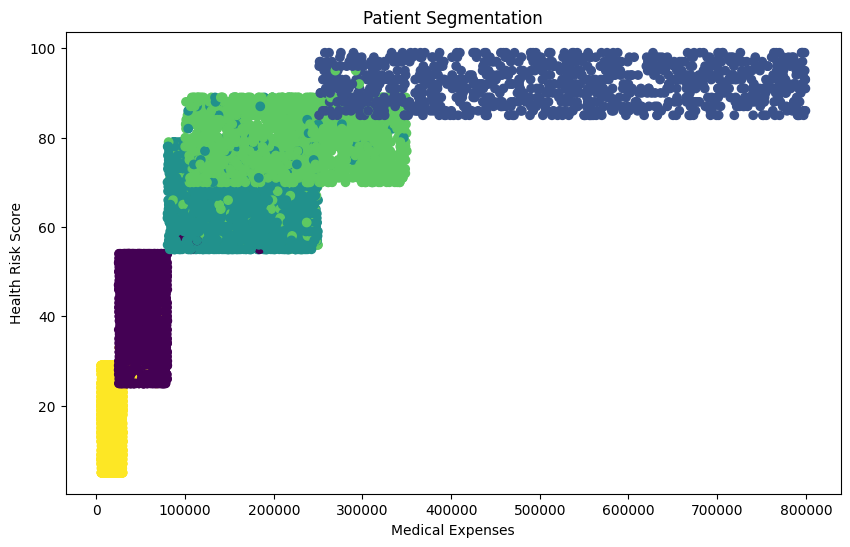

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual_Medical_Expenses"],
    df["Health_Risk_Score"],
    c=df["Cluster"]
)

plt.xlabel(
    "Medical Expenses"
)

plt.ylabel(
    "Health Risk Score"
)

plt.title(
    "Patient Segmentation"
)

plt.show()